# 森林火災：焼失面積と気象・季節・火災危険指数

run_id: `v020-exp-39`。目的は記録された火災の焼失面積との**関連**の記述であり、発火原因・火災発生確率の推定ではない。実行はJupyter MCPのみ。認証情報は出力しない。ゼロを含む全記録と正面積記録を分け、中央値・四分位範囲・順位相関を主に用いる。最大値は誤記と断定せず保持する。

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from contextlib import contextmanager, redirect_stdout, redirect_stderr
from dataclasses import asdict
import os, sys, io, json, hashlib, warnings
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, eda, cleaning, stats_analysis
from ai_data_scientist import data_definition as dd, analysis_assumptions as aa
from ai_data_scientist import data_quality as dq, sensitivity, visualization, notebook_audit
RUN_ID = 'v020-exp-39'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-39-forest-fires')
lifecycle.register_run(RUN_ID, handle.notebook_path)
lifecycle.mark_write_start(RUN_ID)
try:
    pm.ensure_notebook(handle)
    data_dir = pm.ensure_data_dir(handle)
finally:
    lifecycle.mark_write_end(RUN_ID)
@contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を確認しました。')
    lifecycle.mark_execution_start(RUN_ID)
    print('実行開始:', name)
    try:
        yield
    except BaseException:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        print('実行終了:', name)
print('言語:', language_router.detect_language('森林火災の関連を日本語で分析してください'))
print('Notebook:', handle.notebook_path)
print(asdict(lifecycle.get_run_status(RUN_ID)))


言語: ja
Notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-39-forest-fires/notebooks/kaggle-v020-kaggle-exp-39-forest-fires.ipynb
{'run_id': 'v020-exp-39', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-39-forest-fires/notebooks/kaggle-v020-kaggle-exp-39-forest-fires.ipynb', 'reason': None}


In [2]:
with phase('Kaggle公開データ検索'):
    kaggle_log = []
    candidates = []
    api = None
    # 外部API境界で認証情報を含み得る例外本文・SDK出力を抑制する。
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        kaggle_log.append({'step': 'KaggleApi.authenticate', 'status': 'success'})
        for query in ['forest fires weather', 'forest fires', 'forestfires']:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                found = api.dataset_list(search=query, page=1)
            entries = [{'slug': str(d.ref), 'title': str(d.title)} for d in found]
            candidates.extend(entries)
            kaggle_log.append({'step': 'dataset_list', 'search': query, 'status': 'success', 'results': entries})
    except (Exception, SystemExit) as exc:
        kaggle_log.append({'step': 'Kaggle検索', 'status': 'failed', 'error_type': type(exc).__name__, 'message': '認証情報保護のため例外本文とSDK出力は非表示'})
    display(pd.DataFrame(candidates).drop_duplicates() if candidates else pd.DataFrame(kaggle_log))
    print('検索監査:', [{k:v for k,v in row.items() if k != 'results'} for row in kaggle_log])


実行開始: Kaggle公開データ検索
検索監査: [{'step': 'KaggleApi.authenticate', 'status': 'success'}, {'step': 'dataset_list', 'search': 'forest fires weather', 'status': 'success'}, {'step': 'dataset_list', 'search': 'forest fires', 'status': 'success'}, {'step': 'dataset_list', 'search': 'forestfires', 'status': 'success'}]
実行終了: Kaggle公開データ検索


,slug,title
0,sumitm004/forest-fire-area,Forest Fire Area Dataset
1,mbogernetto/brazilian-amazon-rainforest-degrad...,Brazilian Amazon Rainforest Degradation 1999-2019
2,elikplim/forest-fires-data-set,Forest Fires Data Set
3,rtatman/188-million-us-wildfires,1.88 Million US Wildfires
4,ishandutta/forest-fires-data-set-portugal,Forest Fires Data Set Portugal
5,uttam94/forest-forest-dataset,Forest Fire Dataset
6,sudhanshu432/algerian-forest-fires-cleaned-dat...,Algerian Forest Fires Processed Dataset
7,vikasukani/forest-firearea-datasets,Forest Fire-area Datasets.
8,capcloudcoder/us-wildfire-data-plus-other-attr...,U.S. Wildfire data (plus other attributes)
9,imtkaggleteam/wildfires,WildFires 🌲🌴🔥


In [3]:
with phase('Kaggle候補の公開ファイル確認'):
    selected_slug = 'elikplim/forest-fires-data-set'
    if not any(c['slug'] == selected_slug for c in candidates):
        raise RuntimeError('指定候補がKaggle検索結果にないため、推測で取得しません。')
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        files_response = api.dataset_list_files(selected_slug)
    selected_files = [{'name': f.name, 'bytes': f.total_bytes} for f in files_response.files]
    kaggle_log.append({'step': 'dataset_list_files', 'slug': selected_slug, 'status': 'success', 'files': selected_files})
    print(json.dumps(kaggle_log[-1], ensure_ascii=False, indent=2))


実行開始: Kaggle候補の公開ファイル確認
{
  "step": "dataset_list_files",
  "slug": "elikplim/forest-fires-data-set",
  "status": "success",
  "files": [
    {
      "name": "forestfires.csv",
      "bytes": 25478
    }
  ]
}
実行終了: Kaggle候補の公開ファイル確認


In [4]:
with phase('Kaggle取得・識別・辞書確認'):
    import requests, zipfile
    filename = 'forestfires.csv'
    assert filename in [f['name'] for f in selected_files], 'Kaggleに公開されていないファイルは取得しません。'
    csv_path = data_dir / filename
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            api.dataset_download_file(selected_slug, filename, path=str(data_dir), force=True, quiet=True)
    except (Exception, SystemExit) as exc:
        kaggle_log.append({'step': 'dataset_download_file', 'status': 'failed', 'error_type': type(exc).__name__})
        whitepaper_path = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        paper = whitepaper_path.read_text(encoding='utf-8') if whitepaper_path.exists() else ''
        print('取得失敗。white-paper確認:', whitepaper_path.exists())
        print('同一データの公開CSVを明示的に確認できないため、別データに切り替えません。')
        raise RuntimeError('Kaggle取得失敗：例外本文は認証情報保護のため非表示。フォールバック未使用。') from None
    if not csv_path.exists():
        archive = data_dir / (filename + '.zip')
        if not archive.exists():
            raise RuntimeError('ダウンロードAPIは終了しましたがファイルが見つかりません。')
        with zipfile.ZipFile(archive) as z:
            if filename not in z.namelist():
                raise RuntimeError('取得ZIPに公開CSVがありません。')
            csv_path.write_bytes(z.read(filename))
    acquired_at = datetime.now(timezone.utc).isoformat()
    provenance = {'run_id': RUN_ID, 'owner_dataset_slug': selected_slug, 'filename': filename,
                  'retrieved_at_utc': acquired_at, 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(),
                  'bytes': csv_path.stat().st_size, 'source': 'Kaggle Python SDK', 'fallback_used': False}
    kaggle_log.append({'step': 'dataset_download_file', 'status': 'success', **provenance})
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=100000)
    assert not loaded.truncated
    df = loaded.dataframe
    required = {'X','Y','month','day','FFMC','DMC','DC','ISI','temp','RH','wind','rain','area'}
    assert set(df.columns) == required, '焼失面積・気象・火災危険指数を備えた対応データではありません。'
    # CSVではなく原典のメタデータ辞書だけを参照する。別データへの置換ではない。
    dictionary_url = 'https://archive.ics.uci.edu/api/dataset?id=162'
    dictionary_response = requests.get(dictionary_url, timeout=45)
    dictionary_response.raise_for_status()
    dictionary = dictionary_response.json()
    (data_dir / 'uci-dictionary.json').write_text(json.dumps(dictionary, ensure_ascii=False, indent=2), encoding='utf-8')
    (data_dir / 'provenance.json').write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    print(json.dumps(provenance, ensure_ascii=False, indent=2))
    print('形状:', df.shape, '欠損:', int(df.isna().sum().sum()), '完全同一行:', int(df.duplicated().sum()))
    print('データ辞書:', dictionary_url)
    print('原典:', dictionary['data']['name']); print('辞書項目:', json.dumps(dictionary['data']['variables'], ensure_ascii=False))
    display(df.head())


実行開始: Kaggle取得・識別・辞書確認
{
  "run_id": "v020-exp-39",
  "owner_dataset_slug": "elikplim/forest-fires-data-set",
  "filename": "forestfires.csv",
  "retrieved_at_utc": "2026-10-01T22:24:49.845608+00:00",
  "sha256": "0d6586a1fa52f55bef48578aef14eb97273f1e9330e1a53423df497a77065253",
  "bytes": 25478,
  "source": "Kaggle Python SDK",
  "fallback_used": false
}
形状: (517, 13) 欠損: 0 完全同一行: 4
データ辞書: https://archive.ics.uci.edu/api/dataset?id=162
原典: Forest Fires
辞書項目: [{"name": "X", "role": "Feature", "type": "Integer", "demographic": null, "description": "x-axis spatial coordinate within the Montesinho park map: 1 to 9", "units": null, "missing_values": "no"}, {"name": "Y", "role": "Feature", "type": "Integer", "demographic": null, "description": "y-axis spatial coordinate within the Montesinho park map: 2 to 9", "units": null, "missing_values": "no"}, {"name": "month", "role": "Feature", "type": "Categorical", "demographic": null, "description": "month of the year: 'jan' to 'dec' ", "units":

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## データ定義・分析前提・意味的な異常検査

原典のUCI辞書を照合するが、Kaggleミラーと原典のバイト同一性、個々の記録の独立性、ゼロの測定過程、消火活動・燃料・発火原因は未確認。雨の単位は辞書の `mm/m2` をそのまま記録し、通常の降水深へ勝手に換算しない。完全同一行は異なる火災の可能性を排除できないので主分析で保持し、重複除去は感度分析に限る。北半球の暦季節（12–2月、3–5月、6–8月、9–11月）を記述用に定義する。

In [5]:
with phase('定義・前提manifestと意味検査'):
    months = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
    dictionary_vars = {v['name']: v for v in dictionary['data']['variables']}
    variables = {}
    for col in df.columns:
        info = dictionary_vars[col]
        unit = info['units'] if info['units'] else ('FWI指数のスコア（物理単位なし）' if col in ['FFMC','DMC','DC','ISI'] else '暦カテゴリ' if col in ['month','day'] else '地図グリッド座標')
        variables[col] = {'definition': dd.FieldValue(info['description'], 'verified', dictionary_url),
                          'unit': dd.FieldValue(unit, 'verified' if info['units'] or col in ['month','day','X','Y'] else 'inferred', dictionary_url),
                          'actual_dtype': dd.FieldValue(str(df[col].dtype), 'verified', '取得CSV')}
    variables['area']['zero_meaning'] = dd.FieldValue('ゼロの測定・丸め・記録過程は不明。火災なしとは判断しない。', 'unknown', dictionary_url)
    definition_manifest = dd.build_manifest(
        source={k: dd.FieldValue(v, 'verified', 'Kaggle SDKと取得ファイル') for k,v in provenance.items()},
        dataset_scope={'region': dd.FieldValue('Montesinho park, Portugal', 'verified', dictionary_url),
                       'row_unit': dd.FieldValue('火災に関する1記録', 'inferred', 'UCIの目的と項目'),
                       'observation_year': dd.FieldValue('CSVに年・日付・火災IDなし', 'unknown', '取得CSV'),
                       'sampling_frame': dd.FieldValue('全火災・非火災日の母集団や選択過程は不明', 'unknown', dictionary_url)},
        variables=variables, transformations=('元の全517行を保持', '表示用log1p(area)', '正面積部分集団', '北半球暦季節'))
    definition_records = []
    for section, fields in [('source', definition_manifest.source), ('dataset_scope', definition_manifest.dataset_scope)]:
        definition_records += [{'field': section+'.'+k, **asdict(v)} for k,v in fields.items()]
    for col, fields in definition_manifest.variables.items():
        definition_records += [{'field': 'variables.'+col+'.'+k, **asdict(v)} for k,v in fields.items()]
    definition_table = pd.DataFrame(definition_records)
    display(definition_table)
    print('unresolved_fields:', [(k,asdict(v)) for k,v in definition_manifest.unresolved_fields()])
    print('推論項目も別途列挙:', definition_table.loc[definition_table.status.eq('inferred'), ['field','value']].to_dict('records'))
    assumptions_manifest = aa.AnalysisAssumptionManifest(
        analysis_scope={'target': '記録された火災の焼失面積', 'not_target': '発火原因・火災発生確率', 'robust_summary': '中央値/IQR/順位相関'},
        assumptions=(aa.Assumption('zero', 'ゼロを実測値として保持し、非発火と同一視しない', 'verified'),
                     aa.Assumption('iid', '通常bootstrap区間では記録が独立と仮定', 'assumed', impact_if_false='区間が過小になる可能性。空間グリッドclusterを追加検討。', conclusion_critical=True),
                     aa.Assumption('duplicate', '完全同一行も主分析で保持', 'assumed', impact_if_false='同一火災の重複なら重みが過大。除去感度を追加。'),
                     aa.Assumption('season', '北半球の暦季節で分類', 'verified'),
                     aa.Assumption('causality', '観察的・選択された火災記録だけでは因果識別できない', 'verified'),
                     aa.Assumption('sparse', '月別の少数記録は記述のみで一般化しない', 'verified')),
        causal_scope='associational', sampling={'n': len(df), 'seed': 39})
    assumption_findings = aa.check_manifest(assumptions_manifest)
    print('前提manifest:', json.dumps(asdict(assumptions_manifest), ensure_ascii=False, indent=2))
    print('前提検査の全所見:', [asdict(f) for f in assumption_findings])
    schema = {c: {'not_null': True} for c in df.columns}
    schema.update({'X': {'min':1,'max':9,'not_null':True}, 'Y': {'min':2,'max':9,'not_null':True},
                   'month': {'allowed':months,'not_null':True}, 'day': {'allowed':['mon','tue','wed','thu','fri','sat','sun'],'not_null':True},
                   'RH': {'min':0,'max':100,'not_null':True}, 'temp': {'min':-50,'max':60,'not_null':True}})
    for c in ['FFMC','DMC','DC','ISI','wind','rain','area']:
        schema[c] = {'min':0, 'not_null':True}
    schema['FFMC']['max'] = 101
    assert set(schema).issubset(df.columns)
    semantic_anomalies = dq.detect_anomalies(df, schema)
    print('意味的な異常:', [asdict(x) for x in semantic_anomalies])
    print('無限値:', int(np.isinf(df.select_dtypes('number')).sum().sum()))
    duplicate_rows = df.loc[df.duplicated(keep=False)]
    print('重複に関与する行:'); display(duplicate_rows)
    eda_result = eda.explore(df)
    print('EDAは元CSV全列を検査済み。欠損内訳:', df.isna().sum().to_dict()); print('月カテゴリ内訳:', df.month.value_counts().to_dict())
    (data_dir / 'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2), encoding='utf-8')
    (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions_manifest), ensure_ascii=False, indent=2), encoding='utf-8')


実行開始: 定義・前提manifestと意味検査
unresolved_fields: [('dataset_scope.observation_year', {'value': 'CSVに年・日付・火災IDなし', 'status': 'unknown', 'source': '取得CSV'}), ('dataset_scope.sampling_frame', {'value': '全火災・非火災日の母集団や選択過程は不明', 'status': 'unknown', 'source': 'https://archive.ics.uci.edu/api/dataset?id=162'}), ('variables.area.zero_meaning', {'value': 'ゼロの測定・丸め・記録過程は不明。火災なしとは判断しない。', 'status': 'unknown', 'source': 'https://archive.ics.uci.edu/api/dataset?id=162'})]
推論項目も別途列挙: [{'field': 'dataset_scope.row_unit', 'value': '火災に関する1記録'}, {'field': 'variables.FFMC.unit', 'value': 'FWI指数のスコア（物理単位なし）'}, {'field': 'variables.DMC.unit', 'value': 'FWI指数のスコア（物理単位なし）'}, {'field': 'variables.DC.unit', 'value': 'FWI指数のスコア（物理単位なし）'}, {'field': 'variables.ISI.unit', 'value': 'FWI指数のスコア（物理単位なし）'}]
前提manifest: {
  "analysis_scope": {
    "target": "記録された火災の焼失面積",
    "not_target": "発火原因・火災発生確率",
    "robust_summary": "中央値/IQR/順位相関"
  },
  "assumptions": [
    {
      "id": "zero",
      "statement": "ゼロを実測値として保持し

,field,value,status,source
0,source.run_id,v020-exp-39,verified,Kaggle SDKと取得ファイル
1,source.owner_dataset_slug,elikplim/forest-fires-data-set,verified,Kaggle SDKと取得ファイル
2,source.filename,forestfires.csv,verified,Kaggle SDKと取得ファイル
3,source.retrieved_at_utc,2026-10-01T22:24:49.845608+00:00,verified,Kaggle SDKと取得ファイル
4,source.sha256,0d6586a1fa52f55bef48578aef14eb97273f1e9330e1a5...,verified,Kaggle SDKと取得ファイル
5,source.bytes,25478,verified,Kaggle SDKと取得ファイル
6,source.source,Kaggle Python SDK,verified,Kaggle SDKと取得ファイル
7,source.fallback_used,False,verified,Kaggle SDKと取得ファイル
8,dataset_scope.region,"Montesinho park, Portugal",verified,https://archive.ics.uci.edu/api/dataset?id=162
9,dataset_scope.row_unit,火災に関する1記録,inferred,UCIの目的と項目


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
52,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
99,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
214,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
302,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


## 初回分析：ゼロ過多・歪み・頑健な関連

外れ値を削除せず中央値・IQR・90/95/99百分位と最大値、総面積に占める上位記録の割合を併記する。Spearman順位相関は全件と正面積に分ける。記録内の正面積フラグとの相関は「発火確率」ではない。95%bootstrap区間は探索的で、独立性を仮定する。16個の面積関連のp値にはBenjamini–Hochberg補正を併記し、p値だけで判断しない。

In [6]:
with phase('初回頑健分析'):
    from scipy import stats
    weather_indices = ['temp','RH','wind','rain','FFMC','DMC','DC','ISI']
    season_map = {m: ('冬' if m in ['dec','jan','feb'] else '春' if m in ['mar','apr','may'] else '夏' if m in ['jun','jul','aug'] else '秋') for m in months}
    work = df.assign(log_area=np.log1p(df.area), positive=df.area.gt(0).astype(int), season=df.month.map(season_map))
    pos = work.loc[work.area.gt(0)]
    def robust_summary(s):
        return pd.Series({'n': len(s), 'zero_n': int(s.eq(0).sum()), 'zero_pct': 100*s.eq(0).mean(),
                          'median': s.median(), 'Q1': s.quantile(.25), 'Q3': s.quantile(.75), 'IQR': s.quantile(.75)-s.quantile(.25),
                          'P90': s.quantile(.9), 'P95': s.quantile(.95), 'P99': s.quantile(.99), 'max': s.max(),
                          'mean_reference': s.mean(), 'skew_reference': s.skew()})
    summary = pd.DataFrame({'全記録': robust_summary(work.area), '正面積のみ': robust_summary(pos.area)}).T
    print('面積要約（ha）:'); print(summary.round(5).to_string())
    top_share = work.area.nlargest(5).sum()/work.area.sum()
    print(f'上位5記録の総面積割合={top_share:.6f}; 最大記録の割合={work.area.max()/work.area.sum():.6f}')
    print('大面積上位:'); print(work.nlargest(8,'area')[['month','day','area']+weather_indices].to_string(index=False))
    def rho_ci(x, y, seed=39, B=1500):
        x,y = np.asarray(x), np.asarray(y)
        point = stats.spearmanr(x,y)
        rng = np.random.default_rng(seed)
        ids = rng.integers(0,len(x),size=(B,len(x)))
        rx = stats.rankdata(x[ids], axis=1); ry = stats.rankdata(y[ids], axis=1)
        rx -= rx.mean(axis=1,keepdims=True); ry -= ry.mean(axis=1,keepdims=True)
        den = np.sqrt((rx*rx).sum(axis=1)*(ry*ry).sum(axis=1))
        valid = den>0
        samples = (rx[valid]*ry[valid]).sum(axis=1)/den[valid]
        return float(point.statistic), float(point.pvalue), *np.quantile(samples,[.025,.975]), int((~valid).sum())
    rows = []
    for subset_name, frame in [('全記録',work),('正面積のみ',pos)]:
        for j,c in enumerate(weather_indices):
            rho,p,lo,hi,undefined = rho_ci(frame[c],frame.area,seed=39+j)
            rows.append({'subset':subset_name,'variable':c,'n':len(frame),'rho':rho,'p_approx':p,'CI_low':lo,'CI_high':hi,'undefined_bootstrap':undefined})
    associations = pd.DataFrame(rows)
    associations['BH_q'] = stats.false_discovery_control(associations.p_approx.to_numpy(), method='bh')
    print('順位相関と95%探索的区間:'); print(associations.round(6).to_string(index=False))
    binary_assoc = pd.DataFrame([{'variable':c,'rho_recorded_positive':stats.spearmanr(work[c],work.positive).statistic} for c in weather_indices])
    print('記録内正面積フラグとの順位相関:'); print(binary_assoc.round(6).to_string(index=False))
    def group_summary(frame,key,order):
        table = frame.groupby(key, observed=True).area.apply(robust_summary).unstack().reindex(order)
        positive_summary = frame.loc[frame.area.gt(0)].groupby(key,observed=True).area.agg(positive_n='size', positive_median='median', positive_Q1=lambda s:s.quantile(.25),positive_Q3=lambda s:s.quantile(.75))
        table = table.join(positive_summary)
        table['sparse_n_lt20'] = table.n < 20
        return table
    month_summary = group_summary(work,'month',months)
    season_summary = group_summary(work,'season',['冬','春','夏','秋'])
    print('月別（季節の偏り・少数群を明示）:'); print(month_summary.round(4).to_string())
    print('暦季節別:'); print(season_summary.round(4).to_string())
    pearson_diagnostic = stats_analysis.correlation(work,'temp','area',language='ja')
    print('比較用Pearson（頑健な主分析ではない）:', asdict(pearson_diagnostic))
    display(Markdown('Pearsonのモジュール解釈：'+pearson_diagnostic.interpretation+' これは未調整の線形関連であり発火原因ではない。'))
    summary.to_csv(data_dir / 'area-summary.csv')
    associations.to_csv(data_dir / 'spearman-associations.csv',index=False)
    month_summary.to_csv(data_dir / 'month-summary.csv')
    season_summary.to_csv(data_dir / 'season-summary.csv')


実行開始: 初回頑健分析
面積要約（ha）:
           n  zero_n  zero_pct  median    Q1       Q3      IQR     P90     P95       P99      max  mean_reference  skew_reference
全記録    517.0   247.0  47.77563    0.52  0.00   6.5700   6.5700  25.262  48.714  194.7648  1090.84        12.84729        12.84693
正面積のみ  270.0     0.0   0.00000    6.37  2.14  15.4225  13.2825  46.885  84.785  233.2315  1090.84        24.60019         9.44546
上位5記録の総面積割合=0.380827; 最大記録の割合=0.164232
大面積上位:
month day    area  temp  RH  wind  rain  FFMC   DMC    DC  ISI
  sep sat 1090.84  25.1  27   4.0   0.0  92.5 121.1 674.4  8.6
  aug thu  746.28  27.5  27   4.9   0.0  94.8 222.4 698.6 13.9
  jul mon  278.53  22.6  57   4.9   0.0  89.2 103.9 431.6  6.4
  sep tue  212.88  18.8  40   2.2   0.0  91.0 129.5 692.6  7.0
  sep sat  200.94  18.2  46   1.8   0.0  92.5 121.1 674.4  8.6
  aug sun  196.48  19.6  41   5.8   0.0  91.4 142.4 601.4 10.6
  aug wed  185.76  26.2  36   4.5   0.0  91.7 191.4 635.9  7.8
  aug sat  174.63  21.9  42   2.2   0

Pearsonのモジュール解釈：相関係数は 0.0978 (p=0.0261) で、弱い正の相関が見られます。 これは未調整の線形関連であり発火原因ではない。

## 図表の選定

原尺度はゼロへの集中と極端値を、log1p尺度は小面積の構造を確認するために併用する。月別は面積合計だけでなく標本数・ゼロ割合・中央値を表示し、8/9月の件数の多さを母集団の発火率と混同しない。順位相関の区間図は、全件と正面積のみで結論が異なるかを確認する。

実行開始: 図表：原尺度とlog1p尺度
描画警告とメタデータ: [{'title': '焼失面積：ゼロへの集中と極端値', 'xlabel': '焼失面積（ha）', 'ylabel': '記録数', 'legend': '単一系列：全517記録', 'missing_glyphs': [], 'png_bytes': 18962}, {'title': '焼失面積：log1p尺度（ゼロも保持）', 'xlabel': 'log(1 + 焼失面積/ha)', 'ylabel': '記録数', 'legend': '単一系列：全517記録', 'missing_glyphs': [], 'png_bytes': 20125}]
実行終了: 図表：原尺度とlog1p尺度


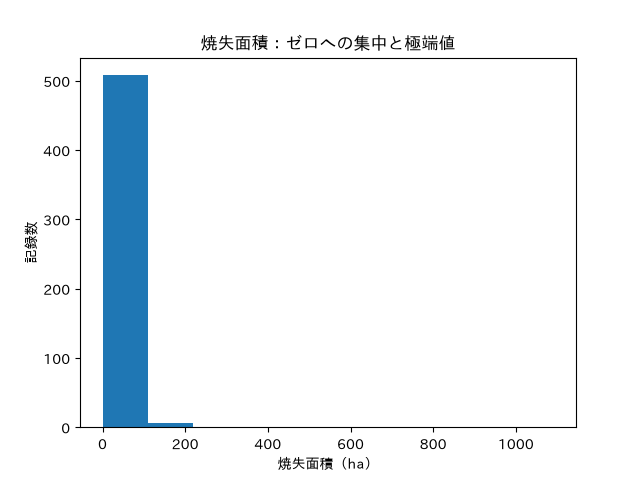

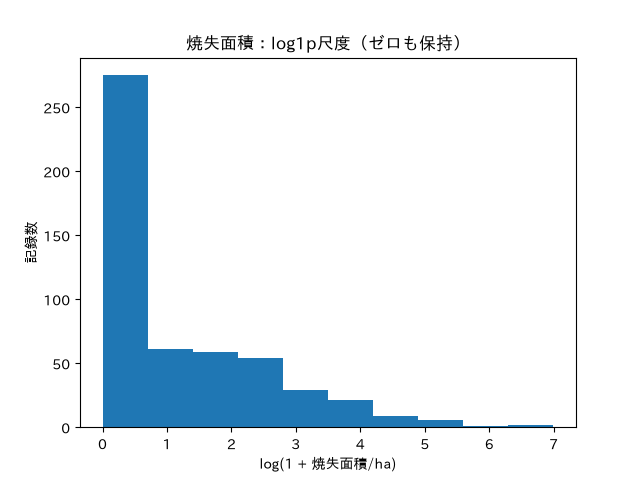

In [7]:
# chart: distributions
with phase('図表：原尺度とlog1p尺度'):
    chart_records = {}
    def show_png(png, title, xlabel, ylabel, legend, caught):
        output = visualization.build_image_output(png)
        display(output['data'], raw=True)
        return {'title':title, 'xlabel':xlabel, 'ylabel':ylabel, 'legend':legend,
                'missing_glyphs':[str(w.message) for w in caught if 'Glyph' in str(w.message)], 'png_bytes':len(png)}
    distribution_meta = []
    for col,title,xlabel in [('area','焼失面積：ゼロへの集中と極端値','焼失面積（ha）'),('log_area','焼失面積：log1p尺度（ゼロも保持）','log(1 + 焼失面積/ha)')]:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            png = visualization.render_chart(work,kind='hist',x=col,title=title,xlabel=xlabel,ylabel='記録数')
        distribution_meta.append(show_png(png,title,xlabel,'記録数','単一系列：全517記録',caught))
    chart_records['distributions'] = {'title':' / '.join(x['title'] for x in distribution_meta),'xlabel':'ha / log1p(ha)','ylabel':'記録数','legend':'全記録','missing_glyphs':sum([x['missing_glyphs'] for x in distribution_meta],[])}
    print('描画警告とメタデータ:', distribution_meta)


実行開始: 図表：月別のゼロと正面積
描画メタデータ: {'title': '月別の記録数・ゼロ割合・正面積中央値', 'xlabel': '月・標本数', 'ylabel': '記録数 / ゼロ割合 / ha', 'legend': '各パネルに凡例あり', 'missing_glyphs': [], 'png_bytes': 82969}
実行終了: 図表：月別のゼロと正面積


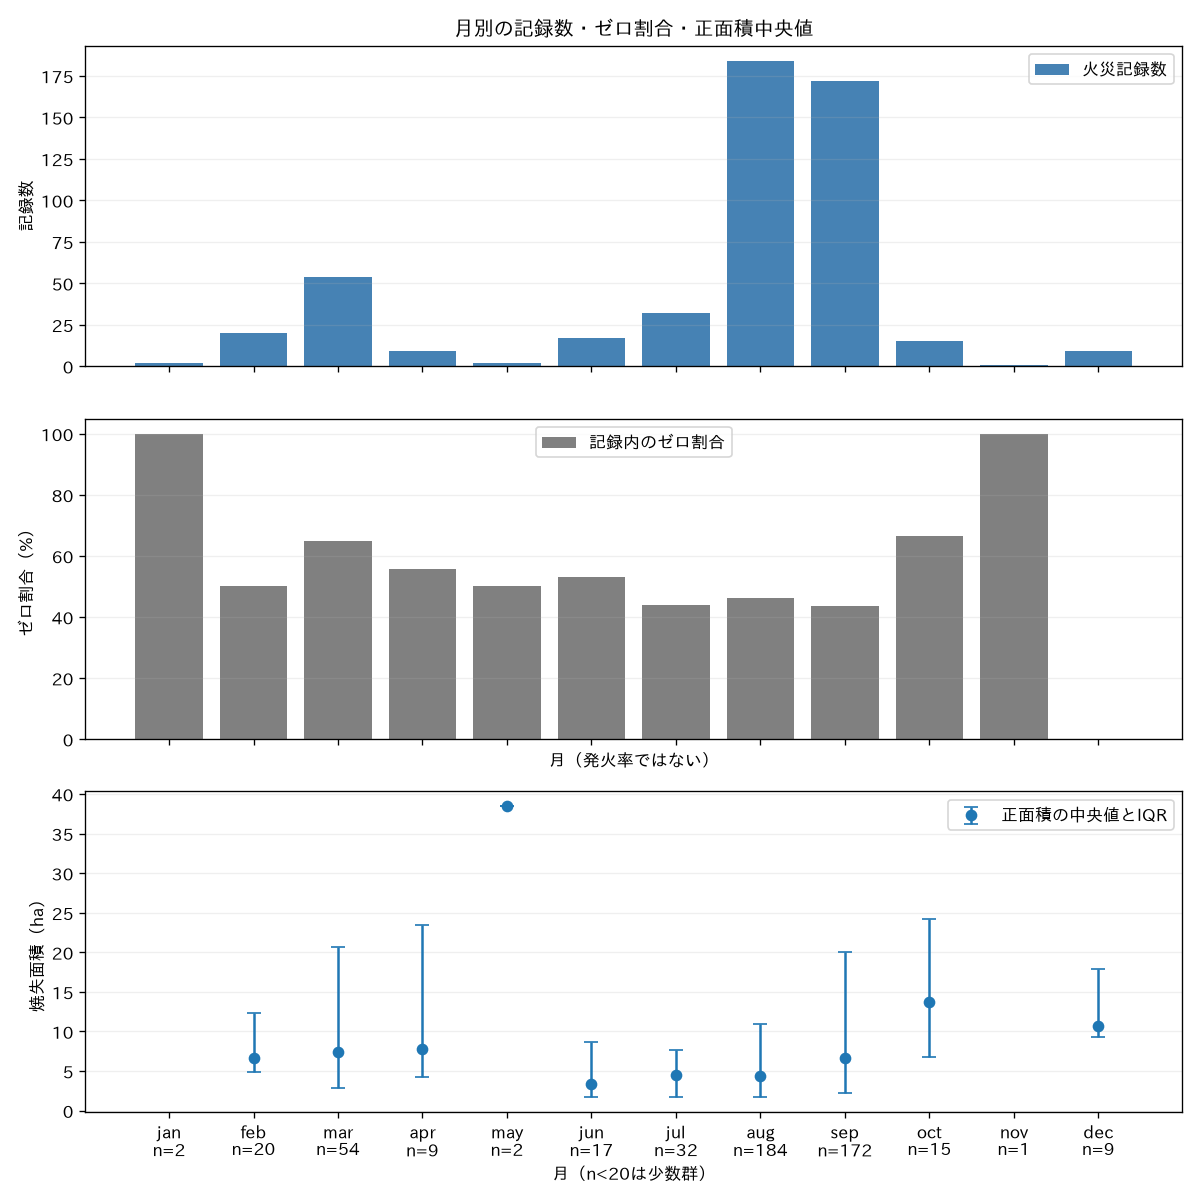

In [8]:
# chart: monthly
with phase('図表：月別のゼロと正面積'):
    import matplotlib.pyplot as plt
    fig,axes = plt.subplots(3,1,figsize=(10,10),sharex=True)
    x = np.arange(12)
    axes[0].bar(x,month_summary.n, color='steelblue',label='火災記録数')
    axes[0].set_ylabel('記録数'); axes[0].set_title('月別の記録数・ゼロ割合・正面積中央値'); axes[0].legend()
    axes[1].bar(x,month_summary.zero_pct,color='gray',label='記録内のゼロ割合')
    axes[1].set_ylabel('ゼロ割合（%）'); axes[1].set_ylim(0,105); axes[1].set_xlabel('月（発火率ではない）'); axes[1].legend()
    med = month_summary.positive_median.to_numpy()
    q1 = month_summary.positive_Q1.to_numpy(); q3 = month_summary.positive_Q3.to_numpy()
    axes[2].errorbar(x,med,yerr=[med-q1,q3-med],fmt='o',capsize=4,label='正面積の中央値とIQR')
    axes[2].set_ylabel('焼失面積（ha）'); axes[2].set_xlabel('月（n<20は少数群）'); axes[2].legend()
    axes[2].set_xticks(x, [m+'\nn='+str(int(month_summary.loc[m,'n'])) for m in months])
    for ax in axes: ax.grid(axis='y',alpha=.2)
    fig.tight_layout()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always'); buf=io.BytesIO(); fig.savefig(buf,format='png',dpi=120)
    plt.close(fig)
    chart_records['monthly'] = show_png(buf.getvalue(),'月別の記録数・ゼロ割合・正面積中央値','月・標本数','記録数 / ゼロ割合 / ha','各パネルに凡例あり',caught)
    print('描画メタデータ:', chart_records['monthly'])


実行開始: 図表：Spearman区間
描画メタデータ: {'title': '面積との順位関連と95%区間', 'xlabel': 'Spearman rho', 'ylabel': '気象・FWI構成指数', 'legend': '全記録 / 正面積のみ', 'missing_glyphs': [], 'png_bytes': 63189}
実行終了: 図表：Spearman区間


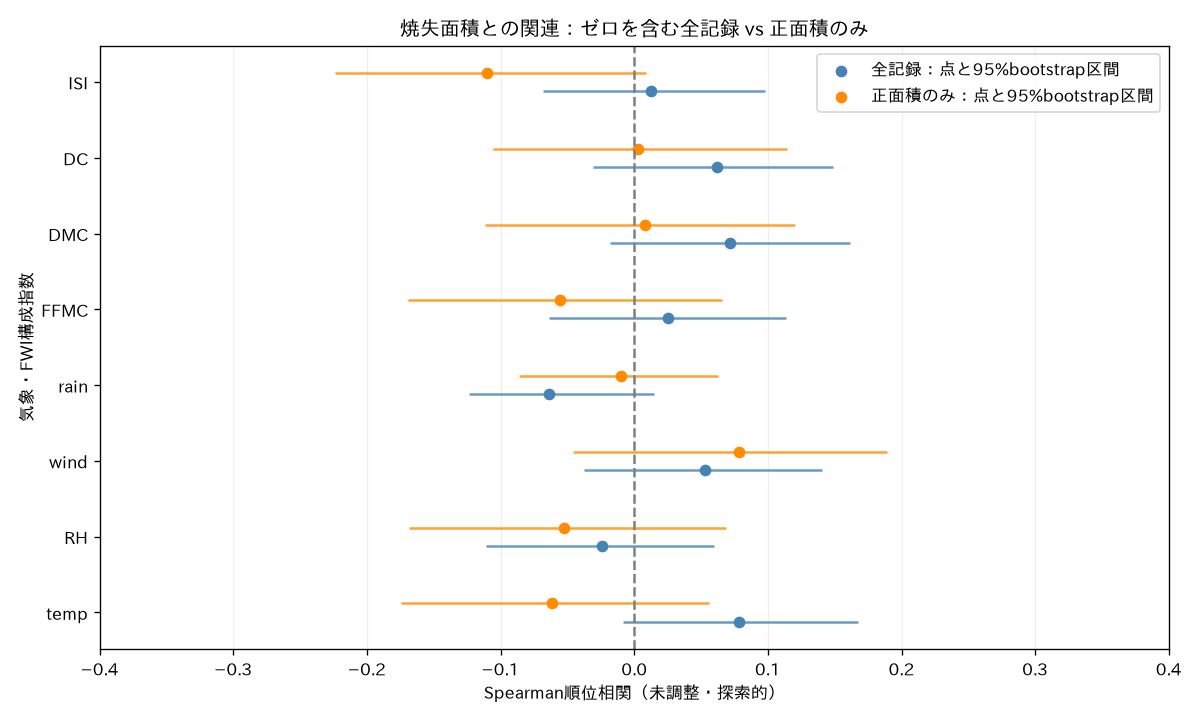

In [9]:
# chart: associations
with phase('図表：Spearman区間'):
    fig,ax = plt.subplots(figsize=(10,6))
    y = np.arange(len(weather_indices))
    for subset,color,offset in [('全記録','steelblue',-.12),('正面積のみ','darkorange',.12)]:
        tab=associations.loc[associations.subset.eq(subset)].set_index('variable').loc[weather_indices]
        r=tab.rho.to_numpy(); lo=tab.CI_low.to_numpy(); hi=tab.CI_high.to_numpy()
        # percentile区間は点推定を含まないことがあるため、端点を直接描く。
        ax.hlines(y+offset,lo,hi,color=color,alpha=.8)
        ax.scatter(r,y+offset,color=color,label=subset+'：点と95%bootstrap区間')
    ax.axvline(0,color='gray',linestyle='--'); ax.set_yticks(y,weather_indices)
    ax.set_xlim(-.4,.4); ax.set_xlabel('Spearman順位相関（未調整・探索的）'); ax.set_ylabel('気象・FWI構成指数')
    ax.set_title('焼失面積との関連：ゼロを含む全記録 vs 正面積のみ'); ax.legend(); ax.grid(axis='x',alpha=.2)
    fig.tight_layout()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always'); buf=io.BytesIO(); fig.savefig(buf,format='png',dpi=120)
    plt.close(fig)
    chart_records['associations'] = show_png(buf.getvalue(),'面積との順位関連と95%区間','Spearman rho','気象・FWI構成指数','全記録 / 正面積のみ',caught)
    print('描画メタデータ:', chart_records['associations'])


## 反復依頼履歴：第1回

**追加依頼文（原文）**

> 初回では全件の順位相関が弱く、正面積だけでは気温の符号が反転しました。上位1%の大面積、完全同一行、月による交絡の扱いを変えても「強い関連を確認できない」という結論が維持されるか調べてください。全件と正面積だけの推定対象は混ぜず、近ゼロの相関に対する相対偏差を頑健性と誤解しないでください。

**選定理由**：上位5記録が総面積の約38%を占め、温度の符号が推定対象で変わるため、外れ値・重複・月調整の影響は結論に関わる。証拠は直後の感度分析セル。

In [10]:
with phase('反復1：上位尾部・重複・月調整の感度'):
    cleaned = cleaning.clean_dataset(df, operation='drop_duplicates')
    print('重複除去の影響:', {'rows_before':cleaned.rows_before,'rows_after':cleaned.rows_after,'rows_removed':cleaned.rows_removed,'columns_affected':cleaned.columns_affected})
    # 感度分析は推定対象（全記録/正面積）ごとに独立して評価する。
    sensitivity_rows = []
    sensitivity_reports = []
    def specification_frame(subset, dedup, trim):
        frame = df.drop_duplicates() if dedup else df.copy()
        if subset == 'positive': frame = frame.loc[frame.area.gt(0)]
        if trim < 1: frame = frame.loc[frame.area.le(frame.area.quantile(trim))]
        return frame
    def rank_association(variable, subset, dedup, trim, adjust_month):
        frame = specification_frame(subset,dedup,trim)
        if adjust_month:
            rx=frame[variable].rank(); ry=frame.area.rank()
            # 月ダミーへの射影残差＝全体順位から月ごとの平均順位を引く。
            rx=rx-rx.groupby(frame.month).transform('mean'); ry=ry-ry.groupby(frame.month).transform('mean')
            if rx.std()==0 or ry.std()==0: raise ValueError('月調整後に変動がなく相関は定義できません。')
            return float(np.corrcoef(rx,ry)[0,1])
        return float(stats.spearmanr(frame[variable],frame.area).statistic)
    plan = sensitivity.SensitivityPlan(parameter_grid={'dedup':[False,True], 'trim':[1.0,.99], 'adjust_month':[False,True]}, max_runs=8)
    for subset in ['all','positive']:
        for c in weather_indices:
            report=sensitivity.run_sensitivity(plan,lambda c=c,subset=subset,**spec:rank_association(c,subset,**spec),stability_tolerance=.2)
            baseline=report.baseline_value
            values=np.array([r.value for r in report.results])
            sensitivity_reports.append({'subset':subset,'variable':c,'stable':report.stable,'max_relative_deviation':report.max_relative_deviation,
                                        'max_absolute_shift':float(np.max(np.abs(values-baseline))),'max_abs_rho':float(np.max(np.abs(values))),
                                        'min_rho':float(values.min()),'max_rho':float(values.max())})
            for r in report.results:
                sensitivity_rows.append({'subset':subset,'variable':c,**r.specification,'rho':r.value,'n':len(specification_frame(subset,r.specification['dedup'],r.specification['trim']))})
    sensitivity_table=pd.DataFrame(sensitivity_rows)
    stability_table=pd.DataFrame(sensitivity_reports)
    print('全128評価の要約:'); print(stability_table.round(6).to_string(index=False))
    print('stableは相対偏差20%以内のモジュール判定。基準rhoが近ゼロなので、Falseだけで強い不安定性と断定しない。')
    print('月調整のみ:'); print(sensitivity_table.loc[~sensitivity_table.dedup & sensitivity_table.trim.eq(1) & sensitivity_table.adjust_month].round(6).to_string(index=False))
    print(f'感度分析全仕様の最大絶対rho={stability_table.max_abs_rho.max():.6f}')
    sensitivity_table.to_csv(data_dir / 'sensitivity-specifications.csv',index=False)
    stability_table.to_csv(data_dir / 'sensitivity-stability.csv',index=False)


実行開始: 反復1：上位尾部・重複・月調整の感度
重複除去の影響: {'rows_before': 517, 'rows_after': 513, 'rows_removed': 4, 'columns_affected': ['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']}
全128評価の要約:
  subset variable  stable  max_relative_deviation  max_absolute_shift  max_abs_rho   min_rho   max_rho
     all     temp   False                0.209067            0.016453     0.095149  0.068097  0.095149
     all       RH   False                0.342481            0.008295     0.024221 -0.024221 -0.015926
     all     wind    True                0.160934            0.008561     0.056929  0.044635  0.056929
     all     rain    True                0.103144            0.006609     0.064662 -0.064662 -0.057465
     all     FFMC   False                0.286326            0.007244     0.032545  0.021561  0.032545
     all      DMC    True                0.147179            0.010585     0.076843  0.061335  0.076843
     all       DC   False                1.184136            

## 第1回の結果と残る限界

128仕様で最大の絶対順位関連は約0.189で、強い単調関連を支持しない。一方、正面積のDMCは月調整で約0.188へ変わるため、「関連がない」「すべて不変」とは言えない。`stable` と `max_relative_deviation` は直前の全16行で報告済みであり、近ゼロ基準の相対偏差の大きさと実質的効果の大きさは区別する。証拠：反復1セルと `sensitivity-specifications.csv`。残る限界：順位化は非単調・交互作用を保証せず、月以外の交絡・記録間依存は未解決。

## 反復依頼履歴：第2回

**追加依頼文（原文）**

> 季節別では冬の正面積中央値が夏より高く見えますが、12月は9件すべて正面積で、季節の標本数も大きく違います。季節ごとの中央値の区間と各月を一つずつ除いた変化を調べ、冬が危険という一般化が適切か検討してください。また、同じ空間グリッドの記録をまとめて再標本化して、初回の相関区間と月調整後DMCの関連が依存性の扱いに左右されるか確認してください。

**選定理由**：季節の見かけの順位とiid前提が結論に影響する。火災ID・実日付がないため、空間グリッドclusterは完全な依存補正ではなく感度分析に限る。

In [11]:
with phase('反復2：季節の小標本と空間cluster'):
    rng=np.random.default_rng(3902)
    season_ci_rows=[]
    for season in ['冬','春','夏','秋']:
        s=pos.loc[pos.season.eq(season),'area'].to_numpy()
        boots=np.median(s[rng.integers(0,len(s),size=(2500,len(s)))],axis=1)
        lo,hi=np.quantile(boots,[.025,.975])
        season_ci_rows.append({'season':season,'positive_n':len(s),'median':float(np.median(s)), 'iid_CI_low':lo,'iid_CI_high':hi})
    season_ci=pd.DataFrame(season_ci_rows)
    print('季節別正面積中央値のiid探索的95%区間:'); print(season_ci.round(5).to_string(index=False))
    loo_rows=[]
    for excluded in months:
        if work.month.eq(excluded).sum()==0: continue
        season=season_map[excluded]
        frame=work.loc[work.season.eq(season) & work.month.ne(excluded)]
        positive=frame.loc[frame.area.gt(0),'area']
        loo_rows.append({'season':season,'excluded_month':excluded,'remaining_n':len(frame),'positive_n':len(positive),
                         'positive_median':positive.median(),'all_median':frame.area.median(),'zero_pct':100*frame.area.eq(0).mean()})
    season_loo=pd.DataFrame(loo_rows)
    print('1か月除外の感度:'); print(season_loo.round(5).to_string(index=False))
    def frame_rho(frame,c,adjust=False):
        rx=frame[c].rank(); ry=frame.area.rank()
        if adjust:
            rx=rx-rx.groupby(frame.month).transform('mean'); ry=ry-ry.groupby(frame.month).transform('mean')
        den=np.sqrt(np.sum((rx-rx.mean())**2)*np.sum((ry-ry.mean())**2))
        if den==0: return np.nan  # 呼出側で未定義件数を明示する。
        return float(np.sum((rx-rx.mean())*(ry-ry.mean()))/den)
    cluster_rows=[]
    for subset,frame in [('all',work),('positive',pos)]:
        groups=[g for _,g in frame.groupby(['X','Y'])]
        specs=[(c,False) for c in ['temp','wind','DMC','ISI']]+[('DMC',True)]
        draws=np.random.default_rng(3903).integers(0,len(groups),size=(1000,len(groups)))
        values={spec:[] for spec in specs}
        for draw in draws:
            resampled=pd.concat([groups[i] for i in draw],ignore_index=True)
            for spec in specs: values[spec].append(frame_rho(resampled,*spec))
        for c,adjust in specs:
            bs=np.asarray(values[(c,adjust)]); valid=bs[np.isfinite(bs)]
            lo,hi=np.quantile(valid,[.025,.975])
            cluster_rows.append({'subset':subset,'variable':c,'month_adjusted':adjust,'n':len(frame),'grid_clusters':len(groups),
                                 'rho':frame_rho(frame,c,adjust),'cluster_CI_low':lo,'cluster_CI_high':hi,'undefined_bootstrap':int((~np.isfinite(bs)).sum())})
    cluster_table=pd.DataFrame(cluster_rows)
    print('空間グリッドcluster探索的95%区間:'); print(cluster_table.round(6).to_string(index=False))
    print('時間的依存、同一日の気象測定、燃料・消火の交絡はこの方法で解消しない。')
    season_ci.to_csv(data_dir/'season-median-bootstrap.csv',index=False)
    season_loo.to_csv(data_dir/'season-leave-one-month-out.csv',index=False)
    cluster_table.to_csv(data_dir/'spatial-cluster-bootstrap.csv',index=False)


実行開始: 反復2：季節の小標本と空間cluster
季節別正面積中央値のiid探索的95%区間:
season  positive_n  median  iid_CI_low  iid_CI_high
     冬          19   9.770       6.380     13.05000
     春          24   7.820       4.610     15.98763
     夏         125   4.250       2.770      6.43525
     秋         102   6.935       5.065     11.06000
1か月除外の感度:
season excluded_month  remaining_n  positive_n  positive_median  all_median  zero_pct
     冬            jan           29          19            9.770        5.39  34.48276
     冬            feb           11           9           10.730        9.77  18.18182
     春            mar           11           5           10.930        0.00  54.54545
     春            apr           56          20            7.820        0.00  64.28571
     春            may           63          23            7.400        0.00  63.49206
     夏            jun          216         117            4.400        0.58  45.83333
     夏            jul          201         107            4.250        0.54  4

## 第2回の結果と残る限界

冬の正面積中央値は9.77ha（19件）だが12月除外で6.61ha（10件）、全記録中央値は5.38haから0haへ変わる。冬が普遍的に危険とは言えない。空間cluster区間は正面積の月調整DMCで約[0.066, 0.348]、未調整ISIで約[-0.200, -0.006]だった。初回iid区間がゼロを含むことだけから「関連なし」と結論づけるのは不適切で、手法依存の探索的信号として扱う。証拠：反復2セルと季節・空間cluster CSV。残る限界：グリッドは火災IDでも実日付でもなく、季節の少数例と年別変動は解決しない。

## 反復依頼履歴：第3回

**追加依頼文（原文）**

> 月調整後の正面積DMCに弱い正の信号が残りました。月内順位という別仕様、8月・9月を除く仕様、空間グリッドを一つずつ除く仕様で確認し、特定群に依存する探索的信号かを整理してください。併せて降雨は正値が8記録しかないため、その8件の構成と正面積割合の正確区間を示し、雨の影響がないと誤解しない説明に修正してください。気象・指数の四分位帯別中央値も確認し、順位相関の弱さが非単調関係の不存在を保証しないことを明記してください。

**選定理由**：反復2で区間推定依存の信号が出た一方、降雨bootstrapで正面積群の175/1500回が未定義になった。信号の一般化と疎データの「無関連」解釈を防ぐため、最後の追加確認とする。

In [12]:
with phase('反復3：DMC信号の限定と降雨の識別限界'):
    dmc_specs=[]
    frames={'正面積全件':pos,'8月除外':pos.loc[pos.month.ne('aug')], '9月除外':pos.loc[pos.month.ne('sep')],
            '8・9月のみ':pos.loc[pos.month.isin(['aug','sep'])], '8・9月除外':pos.loc[~pos.month.isin(['aug','sep'])]}
    for label,frame in frames.items():
        rx=frame.groupby('month').DMC.rank(pct=True); ry=frame.groupby('month').area.rank(pct=True)
        rx=rx-rx.groupby(frame.month).transform('mean'); ry=ry-ry.groupby(frame.month).transform('mean')
        dmc_specs.append({'specification':label,'n':len(frame),'month_adjusted_global_ranks':frame_rho(frame,'DMC',True),
                          'pooled_month_local_rank_rho':float(np.corrcoef(rx,ry)[0,1])})
    dmc_spec_table=pd.DataFrame(dmc_specs)
    print('DMCの代替仕様:'); print(dmc_spec_table.round(6).to_string(index=False))
    grid_loo=[]
    for (gx,gy),group in pos.groupby(['X','Y']):
        frame=pos.loc[~(pos.X.eq(gx)&pos.Y.eq(gy))]
        grid_loo.append({'excluded_X':gx,'excluded_Y':gy,'removed_n':len(group),'n':len(frame),'rho':frame_rho(frame,'DMC',True)})
    grid_loo=pd.DataFrame(grid_loo)
    print('DMC空間grid除外range:',grid_loo.rho.min(),grid_loo.rho.max())
    rx=pos.DMC.rank(); ry=pos.area.rank()
    rx=(rx-rx.groupby(pos.month).transform('mean')).to_numpy()
    ry=(ry-ry.groupby(pos.month).transform('mean')).to_numpy()
    groups=[np.flatnonzero(pos.month.to_numpy()==m) for m in pos.month.unique()]
    denom=np.sqrt(np.sum(rx**2)*np.sum(ry**2)); observed=np.sum(rx*ry)/denom
    rng=np.random.default_rng(3904); permuted=[]
    for _ in range(4000):
        yp=ry.copy()
        for ids in groups: yp[ids]=rng.permutation(ry[ids])
        permuted.append(np.sum(rx*yp)/denom)
    permutation_p=(1+np.sum(np.abs(permuted)>=abs(observed)))/(len(permuted)+1)
    print(f'正面積DMC月内置換：rho={observed:.6f}, p={permutation_p:.6f}, permutations=4000')
    print('追加選択後の未補正探索p値。月内交換可能性を仮定し、空間依存は同時補正しない。')
    rain_rows=[]
    for wet,label in [(False,'雨=0'),(True,'雨>0')]:
        frame=work.loc[work.rain.gt(0).eq(wet)]
        k=int(frame.area.gt(0).sum()); n=len(frame)
        exact=stats.binomtest(k,n).proportion_ci(confidence_level=.95,method='exact')
        rain_rows.append({'group':label,'n':n,'positive_n':k,'zero_n':n-k,'positive_fraction':k/n,
                          'exact_CI_low':exact.low,'exact_CI_high':exact.high,'all_median':frame.area.median(),
                          'positive_median':frame.loc[frame.area.gt(0),'area'].median()})
    rain_summary=pd.DataFrame(rain_rows)
    print('降雨別（正面積割合は火災発生率ではない）:'); print(rain_summary.round(6).to_string(index=False))
    rain_contingency=pd.crosstab(work.rain.gt(0),work.area.gt(0)).reindex(index=[False,True],columns=[False,True],fill_value=0)
    fisher=stats.fisher_exact(rain_contingency.to_numpy())
    print('降雨別正面積フラグFisher exact（探索、独立性仮定）:',asdict(fisher) if hasattr(fisher,'__dataclass_fields__') else {'odds_ratio':fisher.statistic,'p':fisher.pvalue})
    print('降雨正値の全8記録:'); print(work.loc[work.rain.gt(0),['X','Y','month','day','rain','area']].to_string(index=False))
    quantile_rows=[]
    for c in weather_indices:
        if work[c].nunique()<4 or c=='rain': continue
        bands=pd.qcut(work[c],4,duplicates='drop')
        for band,frame in work.groupby(bands,observed=True):
            positive=frame.loc[frame.area.gt(0),'area']
            quantile_rows.append({'variable':c,'band':str(band),'n':len(frame),'zero_pct':100*frame.area.eq(0).mean(),
                                  'all_median':frame.area.median(),'positive_n':len(positive),'positive_median':positive.median(),
                                  'positive_Q1':positive.quantile(.25),'positive_Q3':positive.quantile(.75)})
    quantile_summary=pd.DataFrame(quantile_rows)
    print('四分位帯別頑健要約（未調整、探索）:'); print(quantile_summary.round(4).to_string(index=False))
    print('Spearman rhoが小さいことは非単調・閾値・交互作用の不存在を保証しない。予測/因果推論は行わない。')
    dmc_spec_table.to_csv(data_dir/'dmc-alternative-specifications.csv',index=False)
    grid_loo.to_csv(data_dir/'dmc-leave-grid-out.csv',index=False)
    rain_summary.to_csv(data_dir/'rain-sparse-summary.csv',index=False)
    quantile_summary.to_csv(data_dir/'quartile-band-summary.csv',index=False)


実行開始: 反復3：DMC信号の限定と降雨の識別限界
DMCの代替仕様:
specification   n  month_adjusted_global_ranks  pooled_month_local_rank_rho
        正面積全件 270                     0.187856                     0.207575
         8月除外 171                     0.275131                     0.247082
         9月除外 173                     0.183243                     0.199530
       8・9月のみ 196                     0.154774                     0.180705
       8・9月除外  74                     0.347447                     0.281820
DMC空間grid除外range: 0.1690801033288629 0.24523051057802497
正面積DMC月内置換：rho=0.187856, p=0.003999, permutations=4000
追加選択後の未補正探索p値。月内交換可能性を仮定し、空間依存は同時補正しない。
降雨別（正面積割合は火災発生率ではない）:
group   n  positive_n  zero_n  positive_fraction  exact_CI_low  exact_CI_high  all_median  positive_median
  雨=0 509         268     241           0.526523      0.482118       0.570617        0.55            6.370
  雨>0   8           2       6           0.250000      0.031854       0.650856        0.00            6.495
降雨別正面積フラグFis

## 第3回の結果・反復停止理由

月調整DMCの符号は月内順位、各グリッド除外でも正であり、正面積の弱い関連を探索的信号として残す。月除外では係数が約0.155–0.347に変化するため、効果の大きさは一様ではない。降雨正値8件のうち正面積は2件で、正面積割合の正確95%区間は約3.2–65.1%と広い。降雨の作用がないと結論しない。四分位帯別の未調整中央値も一様な単調パターンではなく、ゼロと正面積、月の構成が重要。証拠：反復3セルおよびDMC・降雨・四分位帯CSV。残る限界：追加選択後のp値、月内交換可能性、時間依存、消火・燃料の未観測交絡、極端火災の少数性。

最大3回の反復を実施した。残る実質的な不確実性は火災ID、年と実日付、ゼロの記録定義、非火災日・曝露、燃料・消火・発火原因など、同じCSVの追加加工では識別できない情報に由来する。高自由度のモデルやさらなる群選択を追加しても根拠を改善しにくいため、追加依頼を作らず停止する。

## 適用しなかった機能と理由

| 機能 | 理由 |
|---|---|
| `data_quality.validate_anomalies` / `dataset_validation.compare_datasets` | 独立した第2データなし。UCIメタデータ辞書は独立観測データではなく、Kaggle同一データのミラーも独立検証と扱わない。 |
| z-scoreによる自動外れ値削除 | ゼロ過多・強い右歪みの面積に正規分布基準は不適切。最大値は意味的な違反なしで保持。除外は感度仕様のみ。 |
| `mcp_gateway.run_and_record` | ホストのJupyter MCPツールを直接呼び出す構成で、kernel内に外部MCP clientを渡していない。同一kernelへの再入呼出は実行待ちになるため利用しない。全分析/APIコードはJupyter MCPの`execute_cell`で実行、ソースは`enqueue_write`で記録した。使用済みモジュールには数えない。 |
| 因果推定、発火分類、発生率推定 | 非火災日・曝露分母・原因・交絡・時系列がなく、関連から発火原因を識別できない。 |
| 総合FWIの分析 | CSVにはFFMC/DMC/DC/ISIのみで総合FWI列がない。名称から総合指数を捏造しない。 |
| 年別・真のイベントcluster・時間ラグ | 年・日付・火災IDが存在しない。曜日は実日付の代わりにならない。 |
| 降雨の通常bootstrap区間を頑健な区間として採用 | 正面積で降雨正値は2件。定数再標本が175/1500回あり、初回区間は定義可能な再標本に限定された条件付き参考値。正確比率区間と8件の実データを併記する。 |

## Jupytermind改善候補

**候補1：図表メタデータ欠落の監査検出漏れ（不具合疑い）**

分類：監査・可視化連携。再現条件：`visualization.build_image_output`のPNGを持つセルに`metadata.chart`を付けず、`notebook_audit.audit_visual_outputs`を呼ぶ。期待：欠落したglyph確認情報・タイトル/軸/凡例メタデータを報告する。実際：欠落したメタデータ辞書を検査せず、描画内容が十分なら所見0件になる（直後の再現セルで記録）。影響：`visual_audit=True`だけでは作者が可読性メタデータを記録し忘れたことを検出できない。回避策：実描画のglyph警告を捕捉し、タイトル/軸/凡例を目視確認して各図セルに`metadata.chart`を明示付与した。関係セル：`# chart:`の3セル、直後の「改善候補の最小再現」セル、最終監査セル。ログ：Notebook出力と`data/jupytermind-improvement-probe.json`。Copilot CLI・Kaggle認証・ベンチマークランナーを使わない最小再現であり、これら固有の問題ではない。

その他：最初の保存先ディレクトリ未作成エラーはJupyter MCPの`use_notebook(mode=create)`の前提条件であり、`project_manager.ensure_notebook`で正常に解消した。Jupytermindの不具合候補には含めない。Kaggle検索・ファイル確認・取得は成功。ベンチマークランナーは未使用。

In [13]:
with phase('改善候補の最小再現'):
    image=visualization.build_image_output(png)
    probe_cell=nbformat.v4.new_code_cell('画像出力の監査再現',execution_count=1,outputs=[image])
    probe=nbformat.v4.new_notebook(cells=[probe_cell])
    probe_findings=notebook_audit.audit_visual_outputs(probe,(0,))
    improvement_probe={'module':'ai_data_scientist.notebook_audit.audit_visual_outputs',
                       'chart_metadata_present':bool(probe_cell.metadata.get('chart')),
                       'expected':'glyphとタイトル/軸/凡例メタデータの欠落を報告',
                       'actual_findings':[asdict(f) for f in probe_findings],
                       'workaround':'実図のメタデータを手動付与しglyph警告を捕捉'}
    print(json.dumps(improvement_probe,ensure_ascii=False,indent=2))
    (data_dir/'jupytermind-improvement-probe.json').write_text(json.dumps(improvement_probe,ensure_ascii=False,indent=2),encoding='utf-8')


実行開始: 改善候補の最小再現
{
  "module": "ai_data_scientist.notebook_audit.audit_visual_outputs",
  "chart_metadata_present": false,
  "expected": "glyphとタイトル/軸/凡例メタデータの欠落を報告",
  "actual_findings": [],
  "workaround": "実図のメタデータを手動付与しglyph警告を捕捉"
}
実行終了: 改善候補の最小再現


## 使用したJupytermindモジュール

間接importを含めず、NotebookとJupyter MCP制御Notebookから**直接import・呼び出した**ものだけを記載する。制御Notebookは `benchmark/v020-exp-39-controller.ipynb`。

| モジュール | 直接呼び出した関数・型 | 使用目的 |
|---|---|---|
| `ai_data_scientist.project_manager` | `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` | slug検証、安定パス、データ保存先、制御Notebookからのソース/証拠/メタデータの直列書込み |
| `ai_data_scientist.language_router` | `detect_language` | 日本語判定 |
| `ai_data_scientist.lifecycle` | `register_run`, `mark_execution_start/end`, `mark_write_start/end`, `is_cancel_requested`, `mark_completed`, `mark_failed`, `get_run_status` | 実行・書込み・失敗・終了状態の追跡 |
| `ai_data_scientist.ingestion` | `SourceSpec`, `ingest` | Kaggle取得CSVの行制限付き読込み、非切詰め確認 |
| `ai_data_scientist.eda` | `explore` | 型、欠損、数値要約、カテゴリ検査 |
| `ai_data_scientist.cleaning` | `clean_dataset` | 完全同一行の除去感度、4行の影響記録（主分析では保持） |
| `ai_data_scientist.stats_analysis` | `correlation` | 比較用Pearsonと日本語解釈。主分析Spearman/区間はSciPyで実装 |
| `ai_data_scientist.data_definition` | `FieldValue`, `build_manifest`, `DataDefinitionManifest.unresolved_fields` | 定義、単位、由来、unknown/inferredの明示 |
| `ai_data_scientist.analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 観察的関連・独立性・記録範囲の前提と所見 |
| `ai_data_scientist.data_quality` | `detect_anomalies` | 範囲、許容カテゴリ、欠損の意味検査 |
| `ai_data_scientist.sensitivity` | `SensitivityPlan`, `run_sensitivity` | 16対象×8仕様、stable/相対偏差/絶対差の報告 |
| `ai_data_scientist.visualization` | `render_chart`, `build_image_output` | 日本語PNGとMIME出力、初回図の生成と最小再現 |
| `ai_data_scientist.insight_engine` | `extract_cited_value`, `record_insight`（制御Notebook） | 実行済み最終根拠セルの出力から文字列を抽出し証拠manifest付き結論を保存 |
| `ai_data_scientist.notebook_audit` | `audit_notebook(visual_audit=True)`, `audit_visual_outputs` | nbformat、全コード実行、証拠、4画像/3セルの可読性監査、改善候補再現 |

分析対象Notebookのセルソース・Markdown・メタデータは`enqueue_write`で書込み、実行出力はJupyter MCPが永続化する。外部脚本、端末、subprocess、作業エージェントは使っていない。

## 最終根拠セル・結論

以下の根拠文字列は実際の計算結果から生成する。結論の証拠manifestは全セル再実行後、制御Notebookがこのセルの永続出力から直接抽出する。一般化対象はこの公開CSV内の記録に限る。

In [14]:
with phase('最終根拠の出力'):
    final_evidence='\n'.join([
        f"zero_n={int(summary.loc['全記録','zero_n'])}; total_n={len(work)}; zero_pct={summary.loc['全記録','zero_pct']:.6f}",
        f"all_median_ha={summary.loc['全記録','median']:.6f}; all_Q1_ha={summary.loc['全記録','Q1']:.6f}; all_Q3_ha={summary.loc['全記録','Q3']:.6f}",
        f"positive_median_ha={summary.loc['正面積のみ','median']:.6f}; positive_Q1_ha={summary.loc['正面積のみ','Q1']:.6f}; positive_Q3_ha={summary.loc['正面積のみ','Q3']:.6f}",
        f"max_area_ha={work.area.max():.6f}; top5_area_share={top_share:.6f}",
        f"initial_max_abs_rho={associations.rho.abs().max():.6f}; min_BH_q={associations.BH_q.min():.6f}",
        f"dmc_positive_month_adjusted_rho={observed:.6f}; dmc_permutation_p={permutation_p:.6f}",
        f"dmc_cluster_CI_low={cluster_table.loc[cluster_table.subset.eq('positive') & cluster_table.variable.eq('DMC') & cluster_table.month_adjusted,'cluster_CI_low'].iloc[0]:.6f}; dmc_cluster_CI_high={cluster_table.loc[cluster_table.subset.eq('positive') & cluster_table.variable.eq('DMC') & cluster_table.month_adjusted,'cluster_CI_high'].iloc[0]:.6f}",
        f"wet_n={int(rain_summary.loc[rain_summary.group.eq('雨>0'),'n'].iloc[0])}; wet_positive_n={int(rain_summary.loc[rain_summary.group.eq('雨>0'),'positive_n'].iloc[0])}",
        f"winter_positive_median_ha={season_ci.loc[season_ci.season.eq('冬'),'median'].iloc[0]:.6f}; winter_without_dec_median_ha={season_loo.loc[season_loo.excluded_month.eq('dec'),'positive_median'].iloc[0]:.6f}",
        'causal_scope=associational; zero_is_not_no_ignition; not_estimated=ignition_cause_or_fire_incidence'])
    display({'text/plain':final_evidence},raw=True)
    print('最終前提検査の全所見（依存性の不確実性は残る）:',[asdict(f) for f in aa.check_manifest(assumptions_manifest)])


実行開始: 最終根拠の出力
最終前提検査の全所見（依存性の不確実性は残る）: [{'code': 'unresolved_conclusion_critical_assumption', 'severity': 'warning', 'message': "Conclusion-critical assumption 'iid' has status 'assumed', not verified/tested.", 'assumption_id': 'iid'}]
実行終了: 最終根拠の出力


zero_n=247; total_n=517; zero_pct=47.775629
all_median_ha=0.520000; all_Q1_ha=0.000000; all_Q3_ha=6.570000
positive_median_ha=6.370000; positive_Q1_ha=2.140000; positive_Q3_ha=15.422500
max_area_ha=1090.840000; top5_area_share=0.380827
initial_max_abs_rho=0.110034; min_BH_q=0.517487
dmc_positive_month_adjusted_rho=0.187856; dmc_permutation_p=0.003999
dmc_cluster_CI_low=0.066482; dmc_cluster_CI_high=0.348488
wet_n=8; wet_positive_n=2
winter_positive_median_ha=9.770000; winter_without_dec_median_ha=6.610000
causal_scope=associational; zero_is_not_no_ignition; not_estimated=ignition_cause_or_fire_incidence

ゼロ面積は記録の約47.8%。ゼロを「火災なし」と同一視せず、全記録と正面積の二部に分けて読む。

```evidence
{"execution_count":14,"cited_value":"zero_n=247; total_n=517; zero_pct=47.775629","claim_type":"descriptive"}
```

面積中央値は全記録0.52ha（Q1–Q3: 0–6.57ha）、正面積6.37ha（2.14–15.4225ha）。最大1090.84haで、上位5件が総面積の約38.1%を占めるため、平均より中央値/IQRと対数図を重視した。

```evidence
{"execution_count":14,"cited_value":"all_median_ha=0.520000; all_Q1_ha=0.000000; all_Q3_ha=6.570000\npositive_median_ha=6.370000; positive_Q1_ha=2.140000; positive_Q3_ha=15.422500\nmax_area_ha=1090.840000; top5_area_share=0.380827","claim_type":"descriptive"}
```

初回の気象・FFMC/DMC/DC/ISIとの未調整順位相関は全記録・正面積とも小さく、最大絶対rhoは約0.110。16比較のBH qはすべて0.05より大きい。ただし「影響がない」や非単調関連の不存在の証明ではない。

```evidence
{"execution_count":14,"cited_value":"initial_max_abs_rho=0.110034; min_BH_q=0.517487","claim_type":"associational"}
```

正面積のDMCは月調整でrho約0.188、空間cluster探索的区間約0.066–0.348。月内順位でも正で、弱い正の関連の探索的信号がある。月除外では約0.155–0.347と大きさは変わり、全件未調整の無関連結論と単純には統合しない。追加選択後の未補正p値・月内交換可能性・cluster定義に依存する。

```evidence
{"execution_count":14,"cited_value":"dmc_positive_month_adjusted_rho=0.187856; dmc_permutation_p=0.003999\ndmc_cluster_CI_low=0.066482; dmc_cluster_CI_high=0.348488","claim_type":"associational"}
```

冬の正面積中央値9.77haは12月除外で6.61haへ変化し、全記録中央値も5.38haから0haへ変わる。冬の普遍的な危険度は推定できない。降雨正値は8件（正面積2件）しかなく、雨の効果がないとは判断できない。

```evidence
{"execution_count":14,"cited_value":"wet_n=8; wet_positive_n=2\nwinter_positive_median_ha=9.770000; winter_without_dec_median_ha=6.610000","claim_type":"descriptive"}
```

以上は観察された火災記録内の関連であり、発火原因ではない。非火災日・曝露分母・燃料・消火・実日付などがなく、火災発生率も因果効果も推定していない。

```evidence
{"execution_count":14,"cited_value":"causal_scope=associational; zero_is_not_no_ignition; not_estimated=ignition_cause_or_fire_incidence","claim_type":"associational"}
```

## 全セル再実行と最終監査

クリーンkernelから全コードセルを上から順にJupyter MCPで再実行し、取得・分析・反復結果の再現を確認する。図表のタイトル/軸/凡例/glyphの実測メタデータは制御Notebookから`enqueue_write`で保存する。最終監査は`visual_audit=True`で実行し、結果・ライフサイクルのcompleted/failedをNotebook出力とデータディレクトリのJSONへ保存する。画像密度の機械的ヒューリスティックは実ピクセルや意味内容の完全検査ではないため、初回4画像の目視読直しも実施した。

In [16]:
with phase('最終Notebook・図表監査'):
    audit_report=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print(json.dumps(asdict(audit_report),ensure_ascii=False,indent=2))
    if not audit_report.ok:
        raise RuntimeError('Notebook監査に未解決のエラーがあります。')
    # メタデータ欠落の検出漏れは個別に補う。
    persisted=nbformat.read(handle.notebook_path,as_version=4)
    for index in audit_report.chart_cell_indices:
        meta=persisted.cells[index].metadata.get('chart',{})
        assert all(k in meta for k in ['title','xlabel','ylabel','legend','missing_glyphs']), '図表メタデータ欠落'
        assert not meta['missing_glyphs'], 'glyph欠落'
    (data_dir/'notebook-audit.json').write_text(json.dumps({'ok':audit_report.ok,**asdict(audit_report)},ensure_ascii=False,indent=2),encoding='utf-8')
lifecycle.mark_completed(RUN_ID)
final_status=asdict(lifecycle.get_run_status(RUN_ID))
print('notebook_audit.ok:',audit_report.ok)
print('lifecycle:',json.dumps(final_status,ensure_ascii=False))
(data_dir/'lifecycle-status.json').write_text(json.dumps(final_status,ensure_ascii=False,indent=2),encoding='utf-8')


実行開始: 最終Notebook・図表監査
{
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-39-forest-fires/notebooks/kaggle-v020-kaggle-exp-39-forest-fires.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 15,
  "executed_code_cell_count": 14,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    10,
    11,
    12
  ],
  "insight_cell_count": 6,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 35
    }
  ],
  "visual_findings": []
}
実行終了: 最終Notebook・図表監査
notebook_audit.ok: True
lifecycle: {"run_id": "v020-exp-39", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-39-forest-fires/notebooks/kaggle-v020-kaggle-exp-39-forest-fires.ipynb

322

## 完了時の永続化後監査

最終監査セルの実行中には自分自身の完了待ち警告が出たが、永続化後の再監査では15/15コードセル実行済み、証拠manifest6件、画像4枚（3セル）、未実行・エラー・図表所見はいずれも0件。全コードセルはクリーンkernelから上から再実行済み。

```json
{
  "ok": true,
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-39-forest-fires/notebooks/kaggle-v020-kaggle-exp-39-forest-fires.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 15,
  "executed_code_cell_count": 15,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    10,
    11,
    12
  ],
  "insight_cell_count": 6,
  "findings": [],
  "visual_findings": [],
  "code_execution_counts_in_order": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    16
  ],
  "clean_kernel_restart": true,
  "analysis_execution_route": "Jupyter MCP",
  "iterations": 3,
  "audited_at_utc": "2026-10-01T22:26:57.401540+00:00"
}
```